# 04 — Training

Train the transformer to predict the next token in Gambler's Ruin sequences
via cross-entropy loss.  Save the best checkpoint to disk.

In [12]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.auto import tqdm

In [13]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


# Resolve project root and add project-local packages/ to sys.path.
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt_root = cwd / "projects" / "markov-chain-learning"
    if (alt_root / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt_root

if project_root is None:
    raise RuntimeError(
        "Could not locate markov-chain-learning project root from current working directory"
    )

packages_dir = project_root / "packages"
if str(packages_dir) not in sys.path:
    sys.path.insert(0, str(packages_dir))

from pytorch_models import MarkovTransformer

## Configuration

In [14]:
# -- Papermill parameters -----------------------------------------------------
DATA_DIR = str(project_root / "experiments" / "single-chain" / "data")
DATA_DIR = Path(DATA_DIR)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


In [15]:
# -- Post-papermill coercions -------------------------------------------------
# Training
BATCH_SIZE = 256  # 256
EPOCHS = 100
LR = 3e-3
VAL_SPLIT = 0.1
SEED = 42
# Save only every N epochs to reduce checkpoint count during fast iteration.
CHECKPOINT_EVERY = 10

EPOCHS = int(EPOCHS)
BATCH_SIZE = int(BATCH_SIZE)
SEED = int(SEED)
CHECKPOINT_EVERY = int(CHECKPOINT_EVERY)

torch.manual_seed(SEED)

## Load data

In [16]:
class MarkovSequenceDataset(Dataset):
    def __init__(self, sequences: torch.Tensor):
        self.data = sequences

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
sequences = data["sequences"]
Ts = data["Ts"]
pis = data["pis"]

data_cfg = data.get("config")
if not isinstance(data_cfg, dict):
    raise KeyError("Dataset is missing required metadata: data['config']")

required_keys = ("n_states", "L")
missing_keys = [k for k in required_keys if k not in data_cfg]
if missing_keys:
    raise KeyError(
        f"Dataset config missing required keys: {missing_keys}. "
        "Regenerate the dataset with 02_dataset.ipynb."
    )

try:
    VOCAB_SIZE = int(data_cfg["n_states"])
    MAX_LEN = int(data_cfg["L"])
except (TypeError, ValueError) as exc:
    raise ValueError(
        "Dataset config keys 'n_states' and 'L' must be integer-like values."
    ) from exc

if VOCAB_SIZE <= 0 or MAX_LEN <= 0:
    raise ValueError(
        f"Dataset config has invalid dimensions: n_states={VOCAB_SIZE}, L={MAX_LEN}"
    )

if int(sequences.shape[1]) != MAX_LEN:
    raise ValueError(
        f"Dataset config mismatch: L={MAX_LEN} but sequences.shape[1]={sequences.shape[1]}"
    )

PAD_ID = int(data_cfg.get("pad_id", -1))
DGP_REGIME = data_cfg.get("dgp_regime", "unknown")

print(f"DGP regime  : {DGP_REGIME}")
print(f"Loaded {len(sequences)} sequences, shape {tuple(sequences.shape)}")
print(
    f"PAD_ID={PAD_ID}, Ts shape: {tuple(Ts.shape)}, VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}"
)

full_ds = MarkovSequenceDataset(sequences)
n_val = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(
    full_ds,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {n_train}   Val: {n_val}")

DGP regime  : single
Loaded 3000 sequences, shape (3000, 10)
PAD_ID=-1, Ts shape: (1, 5, 5), VOCAB_SIZE=5, MAX_LEN=10
Train: 2700   Val: 300


## Training loop

In [17]:
device = torch.device("cpu")
print("Device:", device)

D_MODEL = VOCAB_SIZE * 2
model = MarkovTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    max_len=MAX_LEN,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
print(model)

Device: cpu
MarkovTransformer(
  (input_proj): Linear(in_features=5, out_features=10, bias=False)
  (rel_pos_bias): Embedding(10, 1)
  (layers): ModuleList(
    (0-1): 2 x Attention(
      (W_q): Linear(in_features=10, out_features=10, bias=False)
      (W_k): Linear(in_features=10, out_features=10, bias=False)
      (W_v): Linear(in_features=10, out_features=10, bias=False)
      (W_o): Linear(in_features=10, out_features=10, bias=False)
    )
  )
  (head): Linear(in_features=10, out_features=5, bias=False)
)


In [18]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")

# Per-module breakdown
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:<20} {n:>6,} params")

Total parameters    : 910
Trainable parameters: 910
  input_proj               50 params
  rel_pos_bias             10 params
  layers                  800 params
  head                     50 params


In [19]:
def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, n_tokens = 0.0, 0
    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = batch.to(device)
            x_in = batch[:, :-1]
            x_tgt = batch[:, 1:]
            # Replace PAD_ID with 0 for one_hot encoding (loss ignores these positions)
            x_in = x_in.clone()
            x_in[x_in == PAD_ID] = 0
            logits = model(x_in)
            _, _, vocab_dim = logits.shape
            loss = criterion(logits.reshape(-1, vocab_dim), x_tgt.reshape(-1))

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            valid_tokens = (x_tgt != PAD_ID).sum().item()
            total_loss += loss.item() * valid_tokens
            n_tokens += valid_tokens

    return total_loss / max(n_tokens, 1)


checkpoints_dir = DATA_DIR / "checkpoints"
checkpoints_dir.mkdir(exist_ok=True)

train_losses, val_losses, grad_norms = [], [], []
best_val_loss = float("inf")
ckpt_name = "checkpoint_single_chain.pt"

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    tr_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    gnorm = (
        sum(p.grad.norm().item() ** 2 for p in model.parameters() if p.grad is not None)
        ** 0.5
    )
    grad_norms.append(gnorm)

    epoch_ckpt = {
        "model_state": model.state_dict(),
        "config": dict(vocab_size=VOCAB_SIZE, d_model=D_MODEL, max_len=MAX_LEN),
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_loss": val_loss,
        "training": {
            "architecture": "pytorch_models.MarkovTransformer",
            "dgp_regime": DGP_REGIME,
        },
    }

    if epoch % CHECKPOINT_EVERY == 0 or epoch == EPOCHS:
        torch.save(epoch_ckpt, checkpoints_dir / f"checkpoint_epoch_{epoch:04d}.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {**epoch_ckpt, "best_val_loss": best_val_loss},
            DATA_DIR / ckpt_name,
        )

torch.save(
    {
        "epochs": list(range(1, EPOCHS + 1)),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "grad_norms": grad_norms,
    },
    DATA_DIR / "training_history.pt",
)

print(f"\nBest val loss : {best_val_loss:.4f}  (checkpoint: {ckpt_name})")
print(f"Uniform entropy: {torch.log(torch.tensor(float(VOCAB_SIZE))):.4f}")
print(f"Per-epoch checkpoints saved to: {checkpoints_dir}")

Training:   0%|          | 0/100 [00:00<?, ?it/s]


Best val loss : 1.2716  (checkpoint: checkpoint_single_chain.pt)
Uniform entropy: 1.6094
Per-epoch checkpoints saved to: /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/checkpoints


## Loss curve

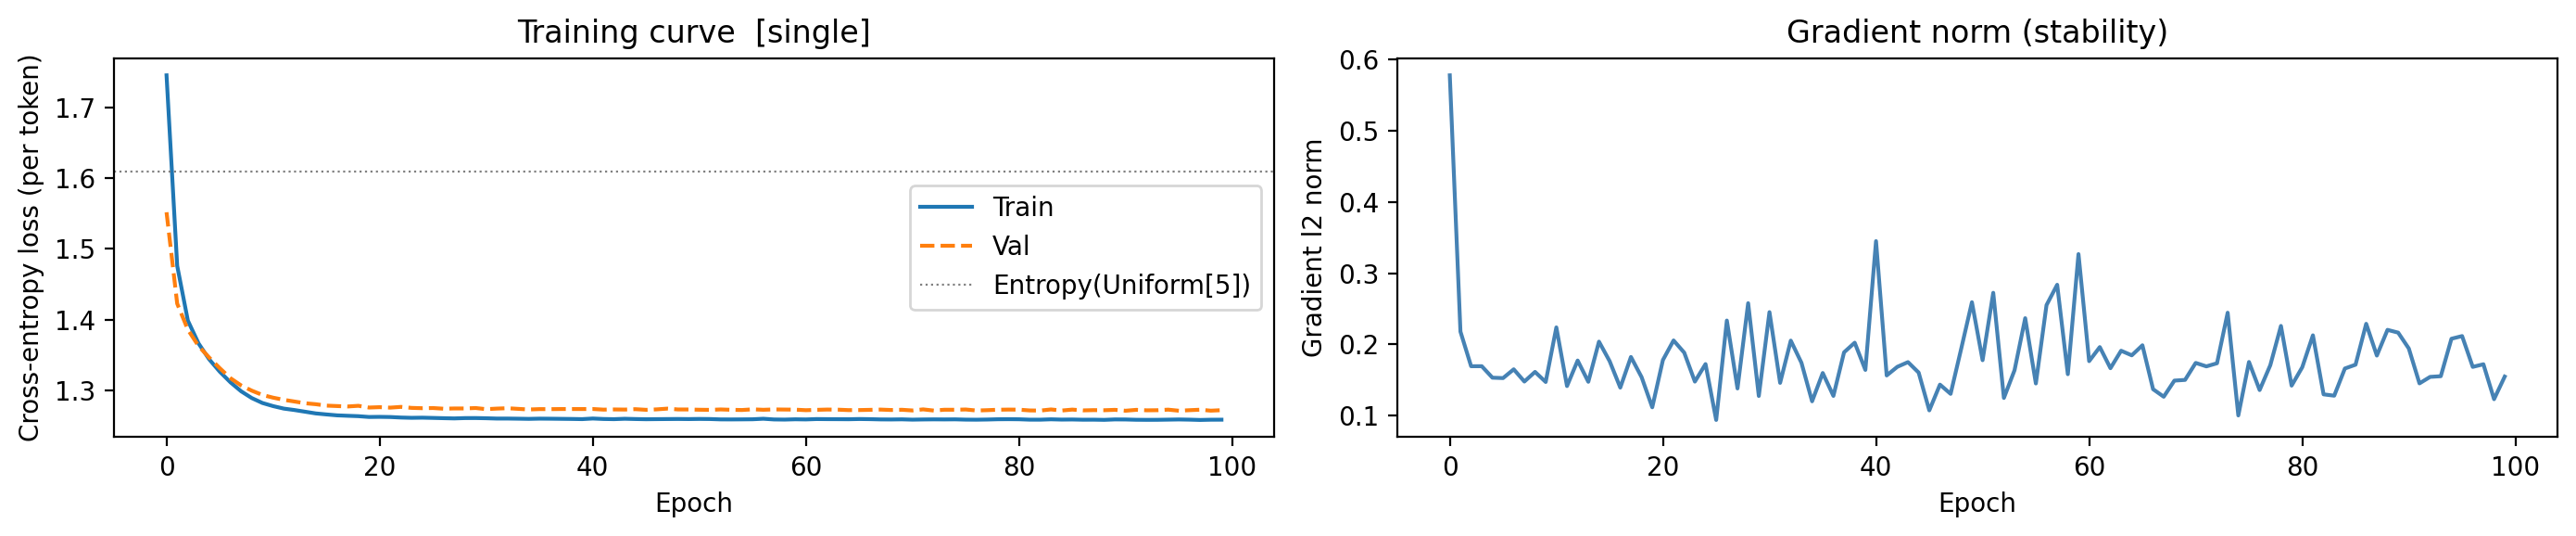

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Val", linestyle="--")
axes[0].axhline(
    torch.log(torch.tensor(float(VOCAB_SIZE))).item(),
    color="gray",
    linestyle=":",
    linewidth=0.8,
    label=f"Entropy(Uniform[{VOCAB_SIZE}])",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss (per token)")
axes[0].set_title(f"Training curve  [{DGP_REGIME}]")
axes[0].legend()

axes[1].plot(grad_norms, color="steelblue")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Gradient l2 norm")
axes[1].set_title("Gradient norm (stability)")

plt.tight_layout()
plt.show()

## Posterior sampling

In [21]:
import torch.nn.functional as F


def loss_fn(logits, targets):
    ce = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
        reduction="none",
        ignore_index=PAD_ID,
    )
    ce = ce.view(logits.shape[:-1])
    mask = (targets != PAD_ID).float()
    return (ce * mask).sum() / mask.sum()


def make_prior_logp(mu: torch.Tensor, sigma=10.0):
    """Gaussian prior N(mu, sigma^2 I) — centred at the MAP."""
    mean = mu.detach().clone()

    def prior_logp(params):
        flat = torch.cat([p.flatten() for p in params])
        diff = flat - mean
        return -0.5 * diff.pow(2).sum() / (sigma**2)

    return prior_logp


def compute_hessian_at_map(model, loss_fn, x_data, y_data):
    """
    Compute approximate Hessian of loss at the current model parameters.
    Returns eigenvalues and eigenvectors.
    """

    # Use approximate Hessian from torch_bdn for efficiency (now with chunking)
    from torch_bdn.bn.bayesian_net import approx_hessian

    H = approx_hessian(model, loss_fn, x_data, y_data, chunk_size=10240)

    # since linalgb must be on cpu we need to move the Hessian back to CPU before eigendecomposition
    H = H.cpu()
    # Compute eigenvalues and eigenvectors
    eigvals, eigvecs = torch.linalg.eigh(H)

    return eigvals, eigvecs, H

## computing hessian

In [22]:
# Prepare data for BayesianNet
x_data = sequences[:, :-1].to(device)
y_data = sequences[:, 1:].to(device)
# Replace PAD_ID with 0 in x_data to avoid one_hot error
x_data = x_data.clone()
x_data[x_data == PAD_ID] = 0

print("\nComputing the Hessian at MLE...")
hessian_results = {}
try:
    eigvals, eigvecs, H = compute_hessian_at_map(model, loss_fn, x_data, y_data)

    hessian_results["eigvals"] = eigvals
    hessian_results["eigvecs"] = eigvecs
    hessian_results["hessian"] = H

    print(f"✓ (λ_min={eigvals[0]:.2e}, λ_max={eigvals[-1]:.2e})")
except Exception as e:
    print(f"✗ Error: {e}")


Computing the Hessian at MLE...
✓ (λ_min=-7.52e-02, λ_max=3.82e+00)


In [ ]:
# === Clamp negative eigenvalues + add prior curvature → PSD mass matrix ===
# The full Hessian at MLE should be PSD, but torch.func.hessian + float32
# chunked averaging introduces numerical errors that flip near-zero
# eigenvalues negative.  Clamp to zero and add prior precision 1/σ².
SIGMA_PRIOR = 10.0

eigvals_clamped = eigvals.clamp(min=0.0)
n_negative = int((eigvals < 0).sum())
n_zero = int((eigvals_clamped == 0).sum())
prior_precision = 1.0 / SIGMA_PRIOR**2

# M = V diag(max(0, λ) + 1/σ²) Vᵀ  — guaranteed PSD with min eigenvalue = 1/σ²
m_eig = eigvals_clamped + prior_precision
M_posterior = eigvecs @ torch.diag(m_eig) @ eigvecs.T

# Condition number of M
cond_M = m_eig.max() / m_eig.min()

# M_posterior_inv = approximate posterior COVARIANCE (Stan convention: M = Σ)
# In non-degenerate dirs: eigenvalue ≈ 1/λ_H (tight posterior)
# In degenerate dirs: eigenvalue ≈ σ² = 100 (prior width — a guess)
m_inv_eig = 1.0 / m_eig
M_posterior_inv = eigvecs @ torch.diag(m_inv_eig) @ eigvecs.T

print(f"Hessian spectrum: {n_negative} negative eigenvalues clamped to 0")
print(f"  λ_min(H) = {eigvals[0]:.4e},  λ_max(H) = {eigvals[-1]:.4e}")
print(f"  After clamp: {n_zero} zero eigenvalues (null space of loss Hessian)")
print(f"  Prior precision: 1/σ² = {prior_precision}")
print(
    f"  M_posterior (precision): eigenvalues [{m_eig.min():.4e}, {m_eig.max():.4e}], cond={cond_M:.1f}"
)
print(
    f"  M_posterior_inv (covariance): eigenvalues [{m_inv_eig.min():.4e}, {m_inv_eig.max():.4e}]"
)

Hessian spectrum: 440 negative eigenvalues clamped to 0
  λ_min(H) = -7.5244e-02,  λ_max(H) = 3.8245e+00
  After clamp: 440 zero eigenvalues (null space of loss Hessian)
  Prior precision: 1/σ² = 0.01
  Mass matrix M = clamp(H,0) + (1/σ²)I
  M eigenvalues: [1.0000e-02, 3.8345e+00]
  Condition number: 383.4


In [24]:
from torch_bdn.bn import BayesianNet
from torch_bdn.sampling import HMC, Perturb, Sampler

# print("\nSampling starting at MLE using HMC with full-matrix mass")

mle_param = torch.cat([p.flatten() for p in model.parameters()]).detach()

In [25]:
# ACF per chain — lowest vs highest variance parameters side by side.
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [ ]:
# === H1: NUTS with identity M + adaptation (pure Stan approach) ===
# No Hessian initialization — let adaptation discover covariance from scratch.
# Increased warmup to 10k so final window has ~3400 draws for 910 dims.
import numpy as np
from torch_bdn.sampling import NUTS

N_CHAINS_NUTS = 1
N_WARMUP = 10000
N_SAMPLES_NUTS = 5000
MAX_TREE_DEPTH = 7

bn = BayesianNet(
    model, loss_fn, make_prior_logp(mle_param, sigma=SIGMA_PRIOR), compile=True
)

result = Sampler(bn, x_data, y_data).sample(
    config=NUTS(
        n_warmup=N_WARMUP,
        step_size=0.01,
        max_tree_depth=MAX_TREE_DEPTH,
        target_accept=0.69,
        # mass_matrix=None → identity start, adaptation discovers covariance
        adapt_mass_matrix=True,
    ),
    n_samples=N_SAMPLES_NUTS,
    n_chains=N_CHAINS_NUTS,
    init_strategy=Perturb(scale=0.1),
    n_cores=1,
)

# ── Save adapted mass matrix for reuse ──
adapted_M = result.chains[0].diagnostics.get("adapted_mass_matrix")
if adapted_M is not None:
    mass_path = DATA_DIR / "adapted_mass_matrix.pt"
    torch.save(adapted_M, mass_path)
    print(f"✓ Saved adapted mass matrix to {mass_path}")
    print(
        f"  shape={tuple(adapted_M.shape)}, cond={adapted_M.svd().S.max() / adapted_M.svd().S.min():.1f}"
    )
else:
    print("⚠ No adapted mass matrix returned (adaptation may not have run)")

# ── Summary ──
import collections

for ci, ch in enumerate(result.chains):
    diag = ch.diagnostics
    n_mass_updates = len(diag.get("warmup_mass_updates", []))
    tree_depths = diag.get("tree_depths", [])
    leapfrog_counts = diag.get("leapfrog_counts", [])
    n_hit_max = diag.get("n_hit_max_depth", 0)
    n_div = diag.get("n_divergences", 0)
    n_samples = len(tree_depths)
    print(
        f"Chain {ci}: accept={ch.acceptance_rate:.3f}  "
        f"ε={diag.get('adapted_step_size', diag['step_size']):.4e}  "
        f"mean_depth={diag.get('mean_tree_depth', 0):.1f}  "
        f"mean_L={diag.get('mean_leapfrog', 0):.0f}  "
        f"mass_updates={n_mass_updates}  "
        f"mass_type={diag.get('mass_type', '?')}"
    )
    print(f"  max_depth_hits={n_hit_max}/{n_samples}  divergences={n_div}/{n_samples}")
    if tree_depths:
        depth_counts = collections.Counter(tree_depths)
        print(f"  Tree depth distribution: {dict(sorted(depth_counts.items()))}")
    if leapfrog_counts:
        print(
            f"  Leapfrog steps: min={min(leapfrog_counts)} "
            f"median={sorted(leapfrog_counts)[len(leapfrog_counts) // 2]} "
            f"max={max(leapfrog_counts)} "
            f"total={sum(leapfrog_counts)}"
        )
    # Show mass adaptation types
    for mu in diag.get("warmup_mass_updates", []):
        print(
            f"    M update @ step {mu['step']}: type={mu['type']}, n_draws={mu['n_draws']}"
        )

  [NUTS warmup] step 10/10000  ε=8.79e-04  depth=7 (hit max)  L=127  α=0.57  divs=4/10  mass=full
  [NUTS warmup] step 20/10000  ε=2.22e-04  depth=7 (hit max)  L=127  α=0.64  divs=1/10  mass=full
  [NUTS warmup] step 30/10000  ε=2.93e-04  depth=7 (hit max)  L=127  α=0.68  divs=0/10  mass=full
  [NUTS warmup] step 40/10000  ε=7.10e-04  depth=7 (hit max)  L=127  α=0.66  divs=0/10  mass=full
  [NUTS warmup] step 50/10000  ε=2.10e-04  depth=7 (hit max)  L=127  α=0.67  divs=0/10  mass=full
  [NUTS warmup] step 60/10000  ε=2.95e-04  depth=7 (hit max)  L=127  α=0.69  divs=0/10  mass=full
  [NUTS warmup] step 70/10000  ε=3.75e-04  depth=7 (hit max)  L=127  α=0.60  divs=0/10  mass=full
  [NUTS warmup] step 80/10000  ε=2.34e-04  depth=7 (hit max)  L=127  α=0.54  divs=3/10  mass=full
  [NUTS warmup] step 90/10000  ε=1.10e-04  depth=7 (hit max)  L=127  α=0.66  divs=1/10  mass=full
  [NUTS warmup] step 100/10000  ε=3.37e-04  depth=7 (hit max)  L=127  α=0.68  divs=0/10  mass=full
  [NUTS warmup] ste

In [42]:
# ── Persist NUTS samples so we don't have to regenerate (2-day run) ──
nuts_path = DATA_DIR / "nuts_samples.pt"

chains_payload = []
for ch in result.chains:
    chains_payload.append(
        {
            "parameters": torch.stack(ch.parameters).cpu(),
            "acceptance_rate": ch.acceptance_rate,
            "diagnostics": ch.diagnostics,
        }
    )

torch.save(
    {
        "chains": chains_payload,
        "config": {
            "n_chains": N_CHAINS_NUTS,
            "n_warmup": N_WARMUP,
            "n_samples": N_SAMPLES_NUTS,
            "sigma_prior": SIGMA_PRIOR,
            "dgp_regime": DGP_REGIME,
        },
        "mle_param": mle_param.cpu(),
        "eigvals": eigvals.cpu(),
        "eigvecs": eigvecs.cpu(),
        "M_posterior": M_posterior.cpu(),
    },
    nuts_path,
)
print(f"✓ Saved NUTS samples to {nuts_path}")
print(
    f"  {len(chains_payload)} chain(s), {chains_payload[0]['parameters'].shape[0]} samples each, d={chains_payload[0]['parameters'].shape[1]}"
)

✓ Saved NUTS samples to /Users/ashrafahmed/workspace/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/nuts_samples.pt
  1 chain(s), 5000 samples each, d=910


In [ ]:
# === H2: NUTS with Hessian-inverse as initial M (covariance convention) ===
# Pass M_posterior_inv = V diag(1/m_eig) Vᵀ as initial mass matrix.
# This is coherent with Stan's M = covariance convention.
# Degenerate dirs get eigenvalue σ² = 100 (prior width).
# Non-degenerate dirs get eigenvalue ≈ 1/λ_H (posterior width).
# Hypothesis: still won't fix ACF because singular geometry is non-Gaussian.

result_h2 = Sampler(bn, x_data, y_data).sample(
    config=NUTS(
        n_warmup=5000,
        step_size=0.01,
        max_tree_depth=7,
        target_accept=0.69,
        mass_matrix=M_posterior_inv,  # Covariance (not precision!) as initial M
        adapt_mass_matrix=True,  # Let adaptation refine from this start
    ),
    n_samples=5000,
    n_chains=1,
    init_strategy=Perturb(scale=0.1),
    n_cores=1,
)

# ── Summary ──
for ci, ch in enumerate(result_h2.chains):
    diag = ch.diagnostics
    n_mass_updates = len(diag.get("warmup_mass_updates", []))
    print(
        f"H2 Chain {ci}: accept={ch.acceptance_rate:.3f}  "
        f"ε={diag.get('adapted_step_size', diag['step_size']):.4e}  "
        f"mean_depth={diag.get('mean_tree_depth', 0):.1f}  "
        f"mass_updates={n_mass_updates}"
    )
    print(
        f"  max_depth_hits={diag.get('n_hit_max_depth', 0)}  divergences={diag.get('n_divergences', 0)}"
    )

Reusing tuned ε = 3.0410e-04
Reusing tuned mass matrix, shape = (910, 910)


TypeError: NUTS.__init__() got an unexpected keyword argument 'adapt_step_size'

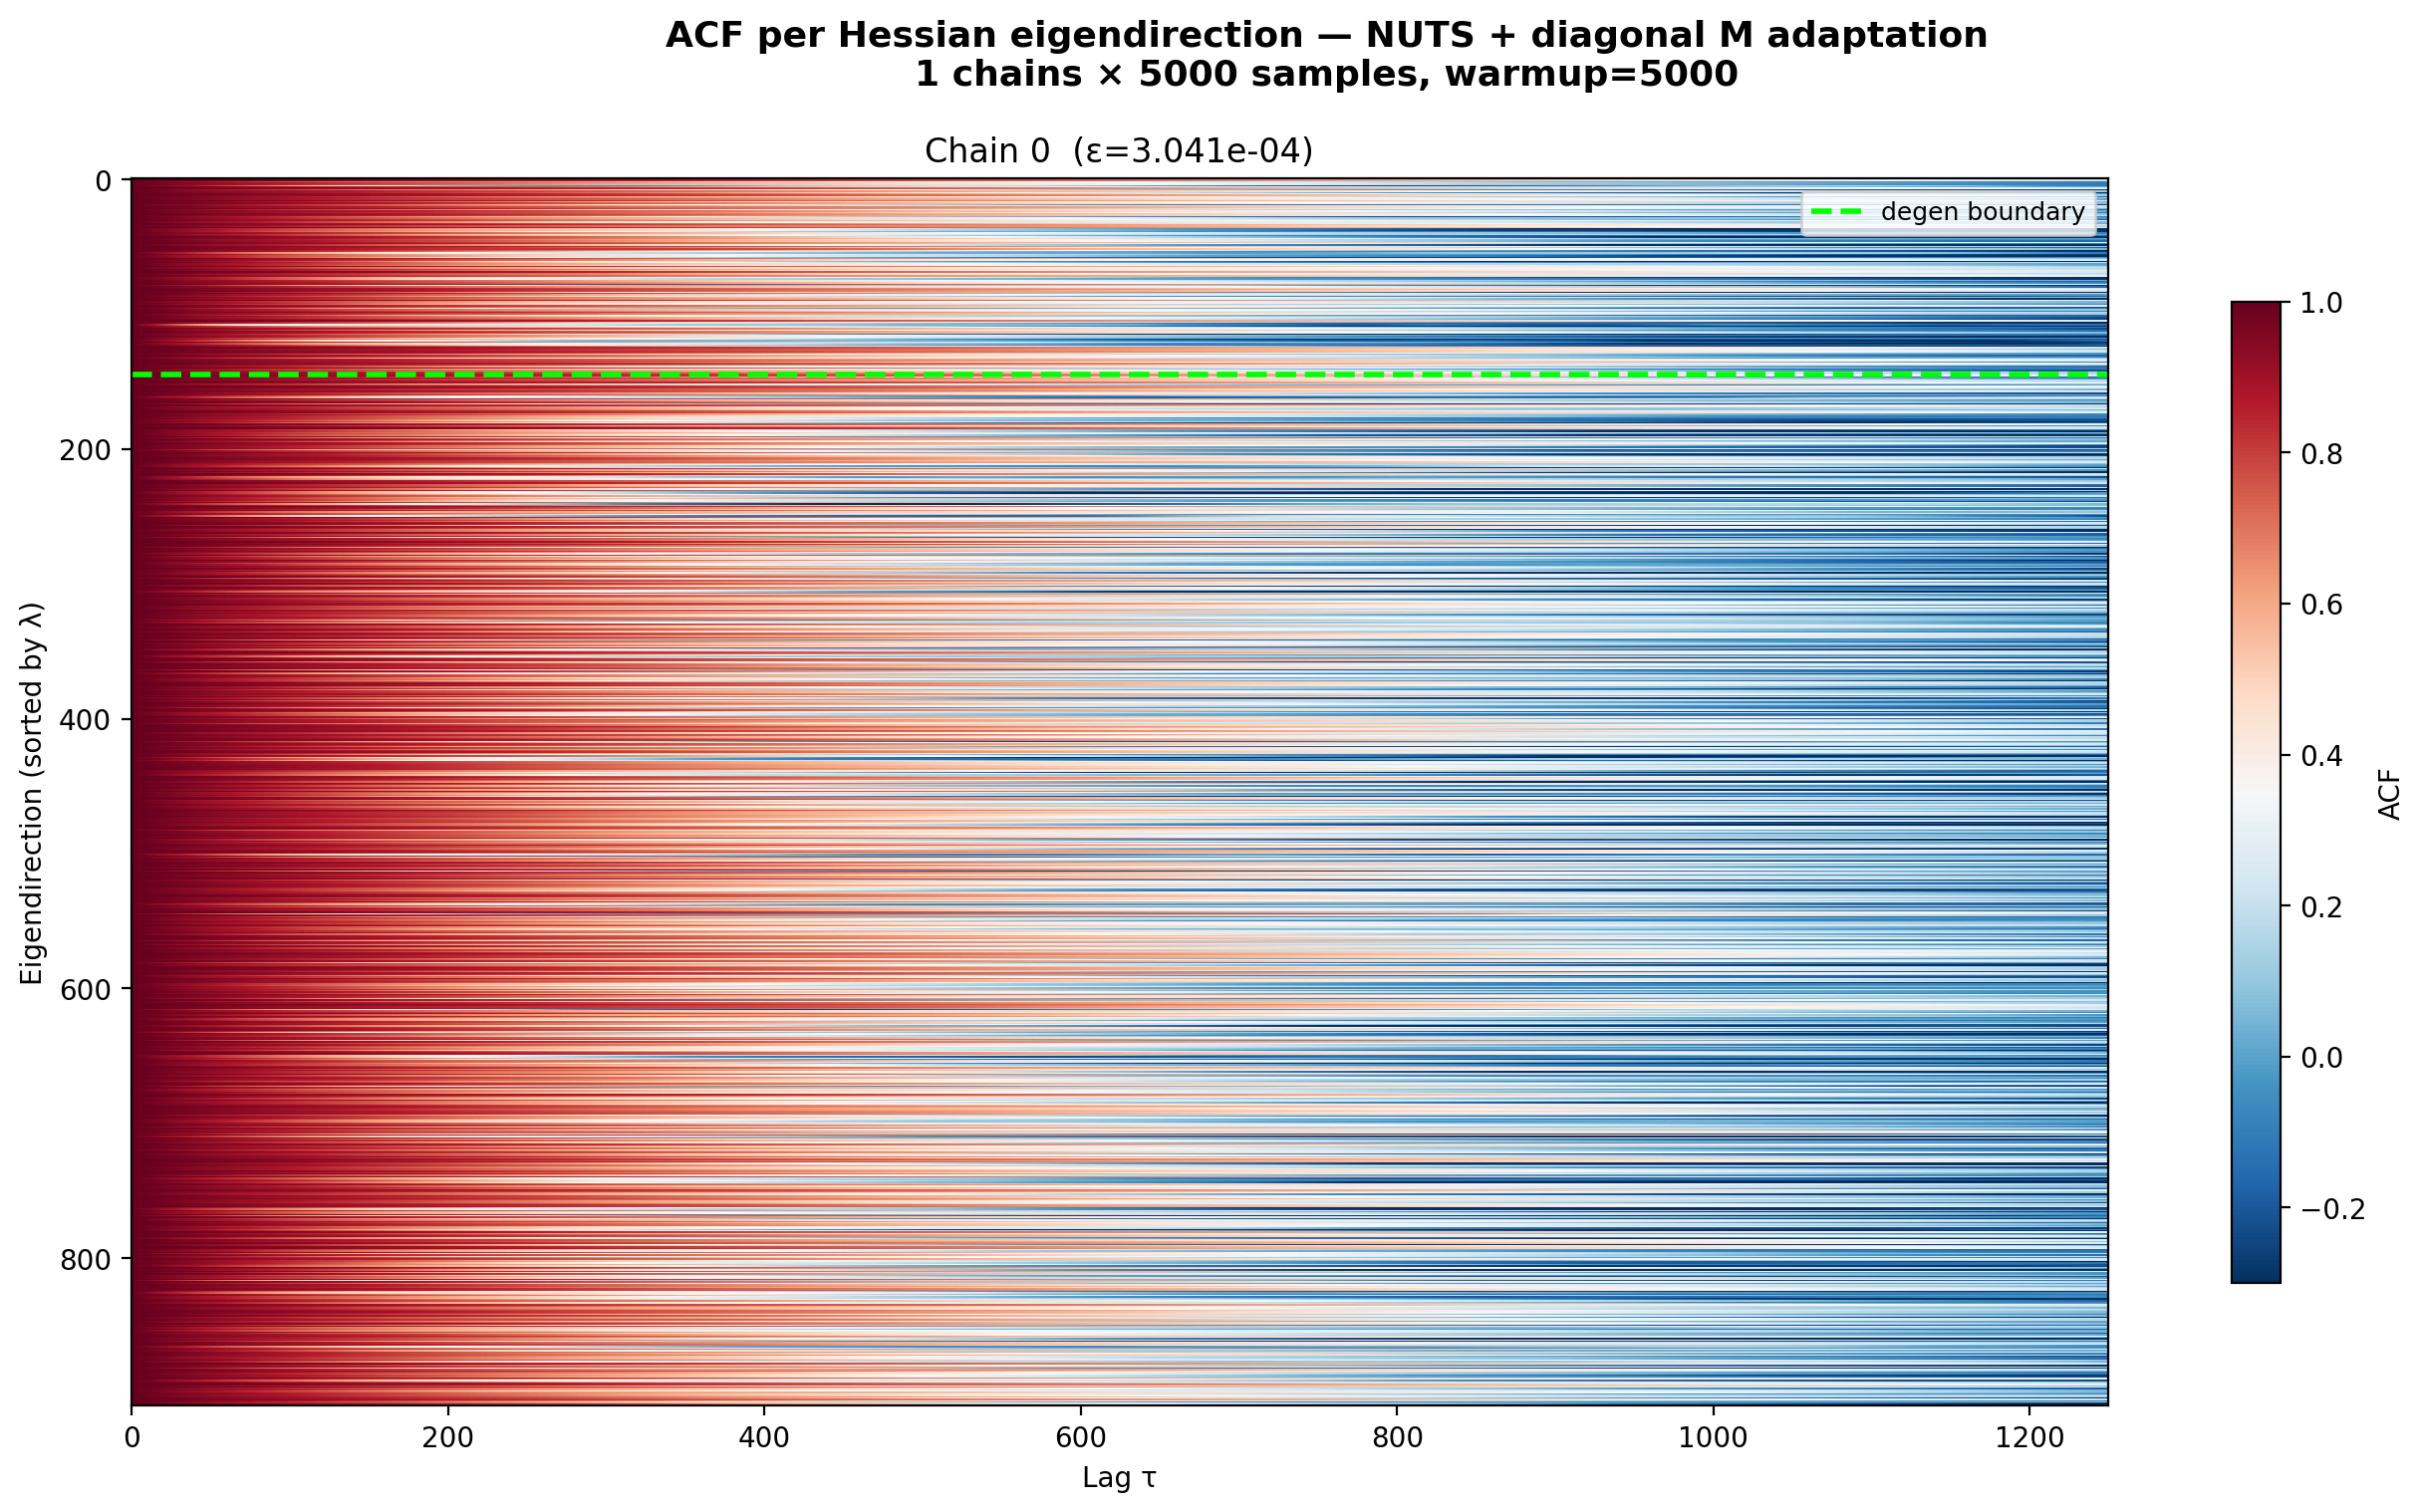


Chain 0:
  ACF@10: median=0.987  max=0.997
  ACF@50: median=0.939  max=0.986


In [48]:
# ── ACF per Hessian eigendirection for each chain ──
V = eigvecs.cpu().float()  # (d, d)  — Hessian eigenbasis
MAX_LAG = min(3000, N_SAMPLES_NUTS // 4)


def compute_acf_eigenbasis(samples_tensor, V, max_lag):
    """Project samples into eigenbasis, compute ACF per direction."""
    z = samples_tensor @ V  # (n_samples, d)
    d = z.shape[1]
    acf = torch.zeros(d, max_lag)
    for j in range(d):
        x = z[:, j]
        x = x - x.mean()
        var = x.var()
        if var < 1e-20:
            continue
        n = x.shape[0]
        padded = torch.zeros(2 * n)
        padded[:n] = x
        ft = torch.fft.rfft(padded)
        acov = torch.fft.irfft(ft * ft.conj())[:n] / n
        acf[j, :max_lag] = acov[:max_lag] / acov[0].clamp(min=1e-20)
    return acf


# Sort by eigenvalue (largest at top)
sort_idx = torch.argsort(eigvals.cpu(), descending=True)
eigvals_sorted = eigvals.cpu()[sort_idx]
eigval_threshold = eigvals.max().item() * 1e-3
n_nd = int((eigvals_sorted.abs() > eigval_threshold).sum())

fig, axes = plt.subplots(1, N_CHAINS_NUTS, figsize=(16, 8), sharey=True, squeeze=False)
axes = axes[0]  # flatten from (1, N) to (N,)
for ci, ch in enumerate(result.chains):
    samps = torch.stack(ch.parameters).cpu().float()
    acf_mat = compute_acf_eigenbasis(samps, V, MAX_LAG)
    acf_sorted = acf_mat[sort_idx]

    ax = axes[ci]
    im = ax.imshow(
        acf_sorted.numpy(),
        aspect="auto",
        cmap="RdBu_r",
        vmin=-0.3,
        vmax=1.0,
        interpolation="nearest",
        origin="upper",
    )
    ax.set_xlabel("Lag τ")
    ax.set_title(f"Chain {ci}  (ε={ch.diagnostics.get('adapted_step_size', 0):.3e})")
    if ci == 0:
        ax.set_ylabel("Eigendirection (sorted by λ)")
    if 0 < n_nd < samps.shape[1]:
        ax.axhline(n_nd - 0.5, color="lime", lw=2, ls="--", label="degen boundary")
        ax.legend(loc="upper right", fontsize=9)

fig.suptitle(
    f"ACF per Hessian eigendirection — NUTS + diagonal M adaptation\n"
    f"{N_CHAINS_NUTS} chains × {N_SAMPLES_NUTS} samples, warmup={N_WARMUP}",
    fontsize=13,
    fontweight="bold",
)
plt.colorbar(im, ax=axes.tolist(), shrink=0.8, label="ACF")
# plt.tight_layout()
plt.show()

# ── Per-chain summary stats ──
for ci, ch in enumerate(result.chains):
    samps = torch.stack(ch.parameters).cpu().float()
    acf_mat = compute_acf_eigenbasis(samps, V, MAX_LAG)[sort_idx]
    acf10 = acf_mat[:, min(10, MAX_LAG - 1)]
    acf50 = acf_mat[:, min(50, MAX_LAG - 1)]
    print(f"\nChain {ci}:")
    print(f"  ACF@10: median={acf10.median():.3f}  max={acf10.max():.3f}")
    print(f"  ACF@50: median={acf50.median():.3f}  max={acf50.max():.3f}")

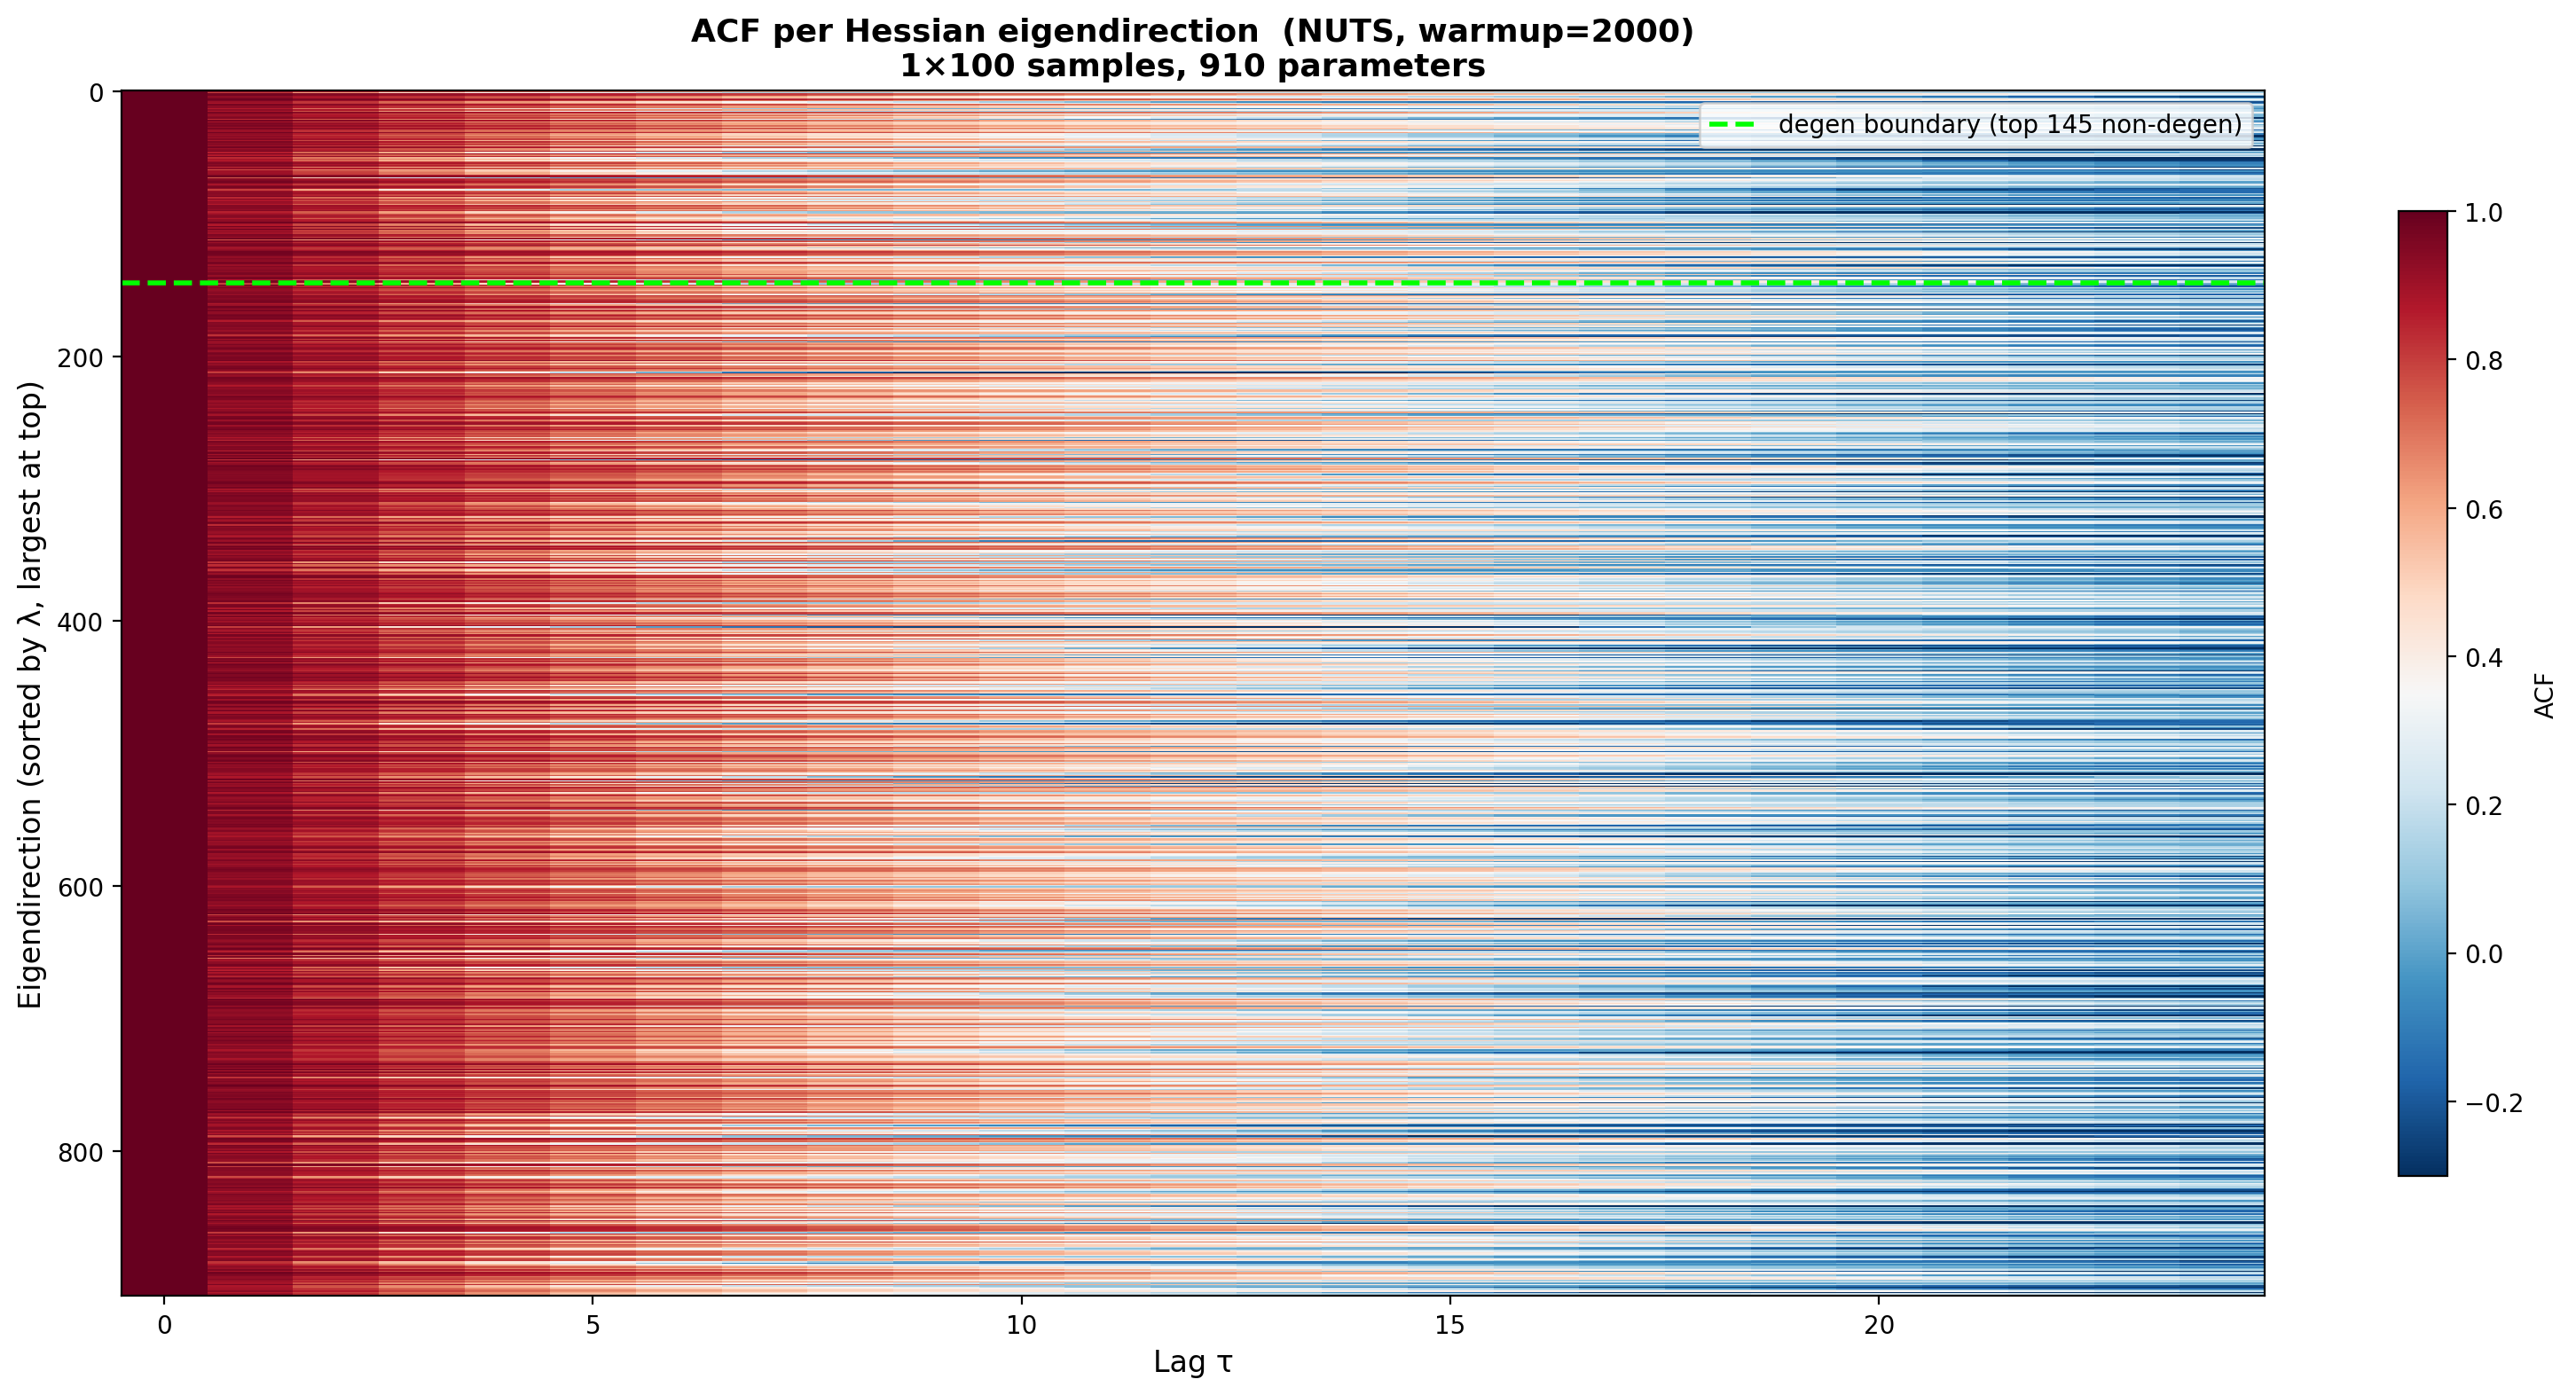


ACF at lag 10:  median=0.504,  max=0.802,  min=-0.320
ACF at lag 50:  median=0.062,  max=0.355,  min=-0.561


In [ ]:
# === Option B: ACF heatmap — scalar ACF per Hessian eigendirection ===
# Build (n_chains, n_samples, d) tensor from NUTS result, then concat across chains.
all_samples = (
    torch.stack([torch.stack(ch.parameters) for ch in result.chains]).cpu().float()
)  # (n_chains, n_samples, d)

V = eigvecs.cpu().float()  # (d, d)
concat_samples = all_samples.reshape(-1, all_samples.shape[-1])  # (N_total, d)
z = concat_samples @ V  # (N_total, d) — samples in eigenbasis

MAX_LAG = min(500, z.shape[0] // 4)
d = z.shape[1]

# Compute ACF for each eigendirection via FFT
acf_matrix = torch.zeros(d, MAX_LAG)
for j in range(d):
    x = z[:, j]
    x = x - x.mean()
    var = x.var()
    if var < 1e-20:
        acf_matrix[j, :] = 0.0
        continue
    n = x.shape[0]
    padded = torch.zeros(2 * n)
    padded[:n] = x
    ft = torch.fft.rfft(padded)
    acov = torch.fft.irfft(ft * ft.conj())[:n] / n
    acf_matrix[j, :MAX_LAG] = acov[:MAX_LAG] / acov[0].clamp(min=1e-20)

# Sort by eigenvalue (largest at top)
sort_idx = torch.argsort(eigvals.cpu(), descending=True)
acf_sorted = acf_matrix[sort_idx]
eigvals_sorted = eigvals.cpu()[sort_idx]

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(
    acf_sorted.numpy(),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=1.0,
    interpolation="nearest",
    origin="upper",
)
ax.set_xlabel("Lag τ", fontsize=12)
ax.set_ylabel("Eigendirection (sorted by λ, largest at top)", fontsize=12)
ax.set_title(
    f"ACF per Hessian eigendirection  (NUTS, warmup={N_WARMUP})\n"
    f"{N_CHAINS_NUTS}×{N_SAMPLES_NUTS} samples, {d} parameters",
    fontsize=13,
    fontweight="bold",
)

# Mark the degenerate/non-degenerate boundary
eigval_threshold = eigvals.max().item() * 1e-3
n_nd = int((eigvals_sorted.abs() > eigval_threshold).sum())
if 0 < n_nd < d:
    ax.axhline(
        n_nd - 0.5,
        color="lime",
        linewidth=2,
        linestyle="--",
        label=f"degen boundary (top {n_nd} non-degen)",
    )
    ax.legend(loc="upper right", fontsize=10)

plt.colorbar(im, ax=ax, shrink=0.8, label="ACF")
plt.tight_layout()
plt.show()

# Print summary stats
acf_at_10 = acf_sorted[:, min(10, MAX_LAG - 1)]
acf_at_50 = acf_sorted[:, min(50, MAX_LAG - 1)]
print(
    f"\nACF at lag 10:  median={acf_at_10.median():.3f},  max={acf_at_10.max():.3f},  min={acf_at_10.min():.3f}"
)
print(
    f"ACF at lag 50:  median={acf_at_50.median():.3f},  max={acf_at_50.max():.3f},  min={acf_at_50.min():.3f}"
)

In [ ]:
# === H2 ACF comparison ===
# Same eigenbasis ACF analysis as above, but for H2 (M_posterior_inv init).
samps_h2 = torch.stack(result_h2.chains[0].parameters).cpu().float()
acf_h2 = compute_acf_eigenbasis(samps_h2, V, MAX_LAG)[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
for ax, (acf_data, label) in zip(
    axes,
    [
        (acf_sorted, "H1: Identity M + adapt"),
        (acf_h2.numpy(), "H2: M_posterior_inv + adapt"),
    ],
):
    im = ax.imshow(
        acf_data if isinstance(acf_data, np.ndarray) else acf_data.numpy(),
        aspect="auto",
        cmap="RdBu_r",
        vmin=-0.3,
        vmax=1.0,
        interpolation="nearest",
        origin="upper",
    )
    ax.set_xlabel("Lag τ")
    ax.set_title(label)
    if 0 < n_nd < samps_h2.shape[1]:
        ax.axhline(n_nd - 0.5, color="lime", lw=2, ls="--")
axes[0].set_ylabel("Eigendirection (sorted by λ)")
fig.suptitle("H1 vs H2: ACF per Hessian eigendirection", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=axes.tolist(), shrink=0.8, label="ACF")
plt.show()

# Summary
acf10_h1 = acf_sorted[:, min(10, MAX_LAG - 1)]
acf50_h1 = acf_sorted[:, min(50, MAX_LAG - 1)]
acf10_h2 = acf_h2[:, min(10, MAX_LAG - 1)]
acf50_h2 = acf_h2[:, min(50, MAX_LAG - 1)]
print(
    f"H1 — ACF@10: median={acf10_h1.median():.3f}  ACF@50: median={acf50_h1.median():.3f}"
)
print(
    f"H2 — ACF@10: median={acf10_h2.median():.3f}  ACF@50: median={acf50_h2.median():.3f}"
)

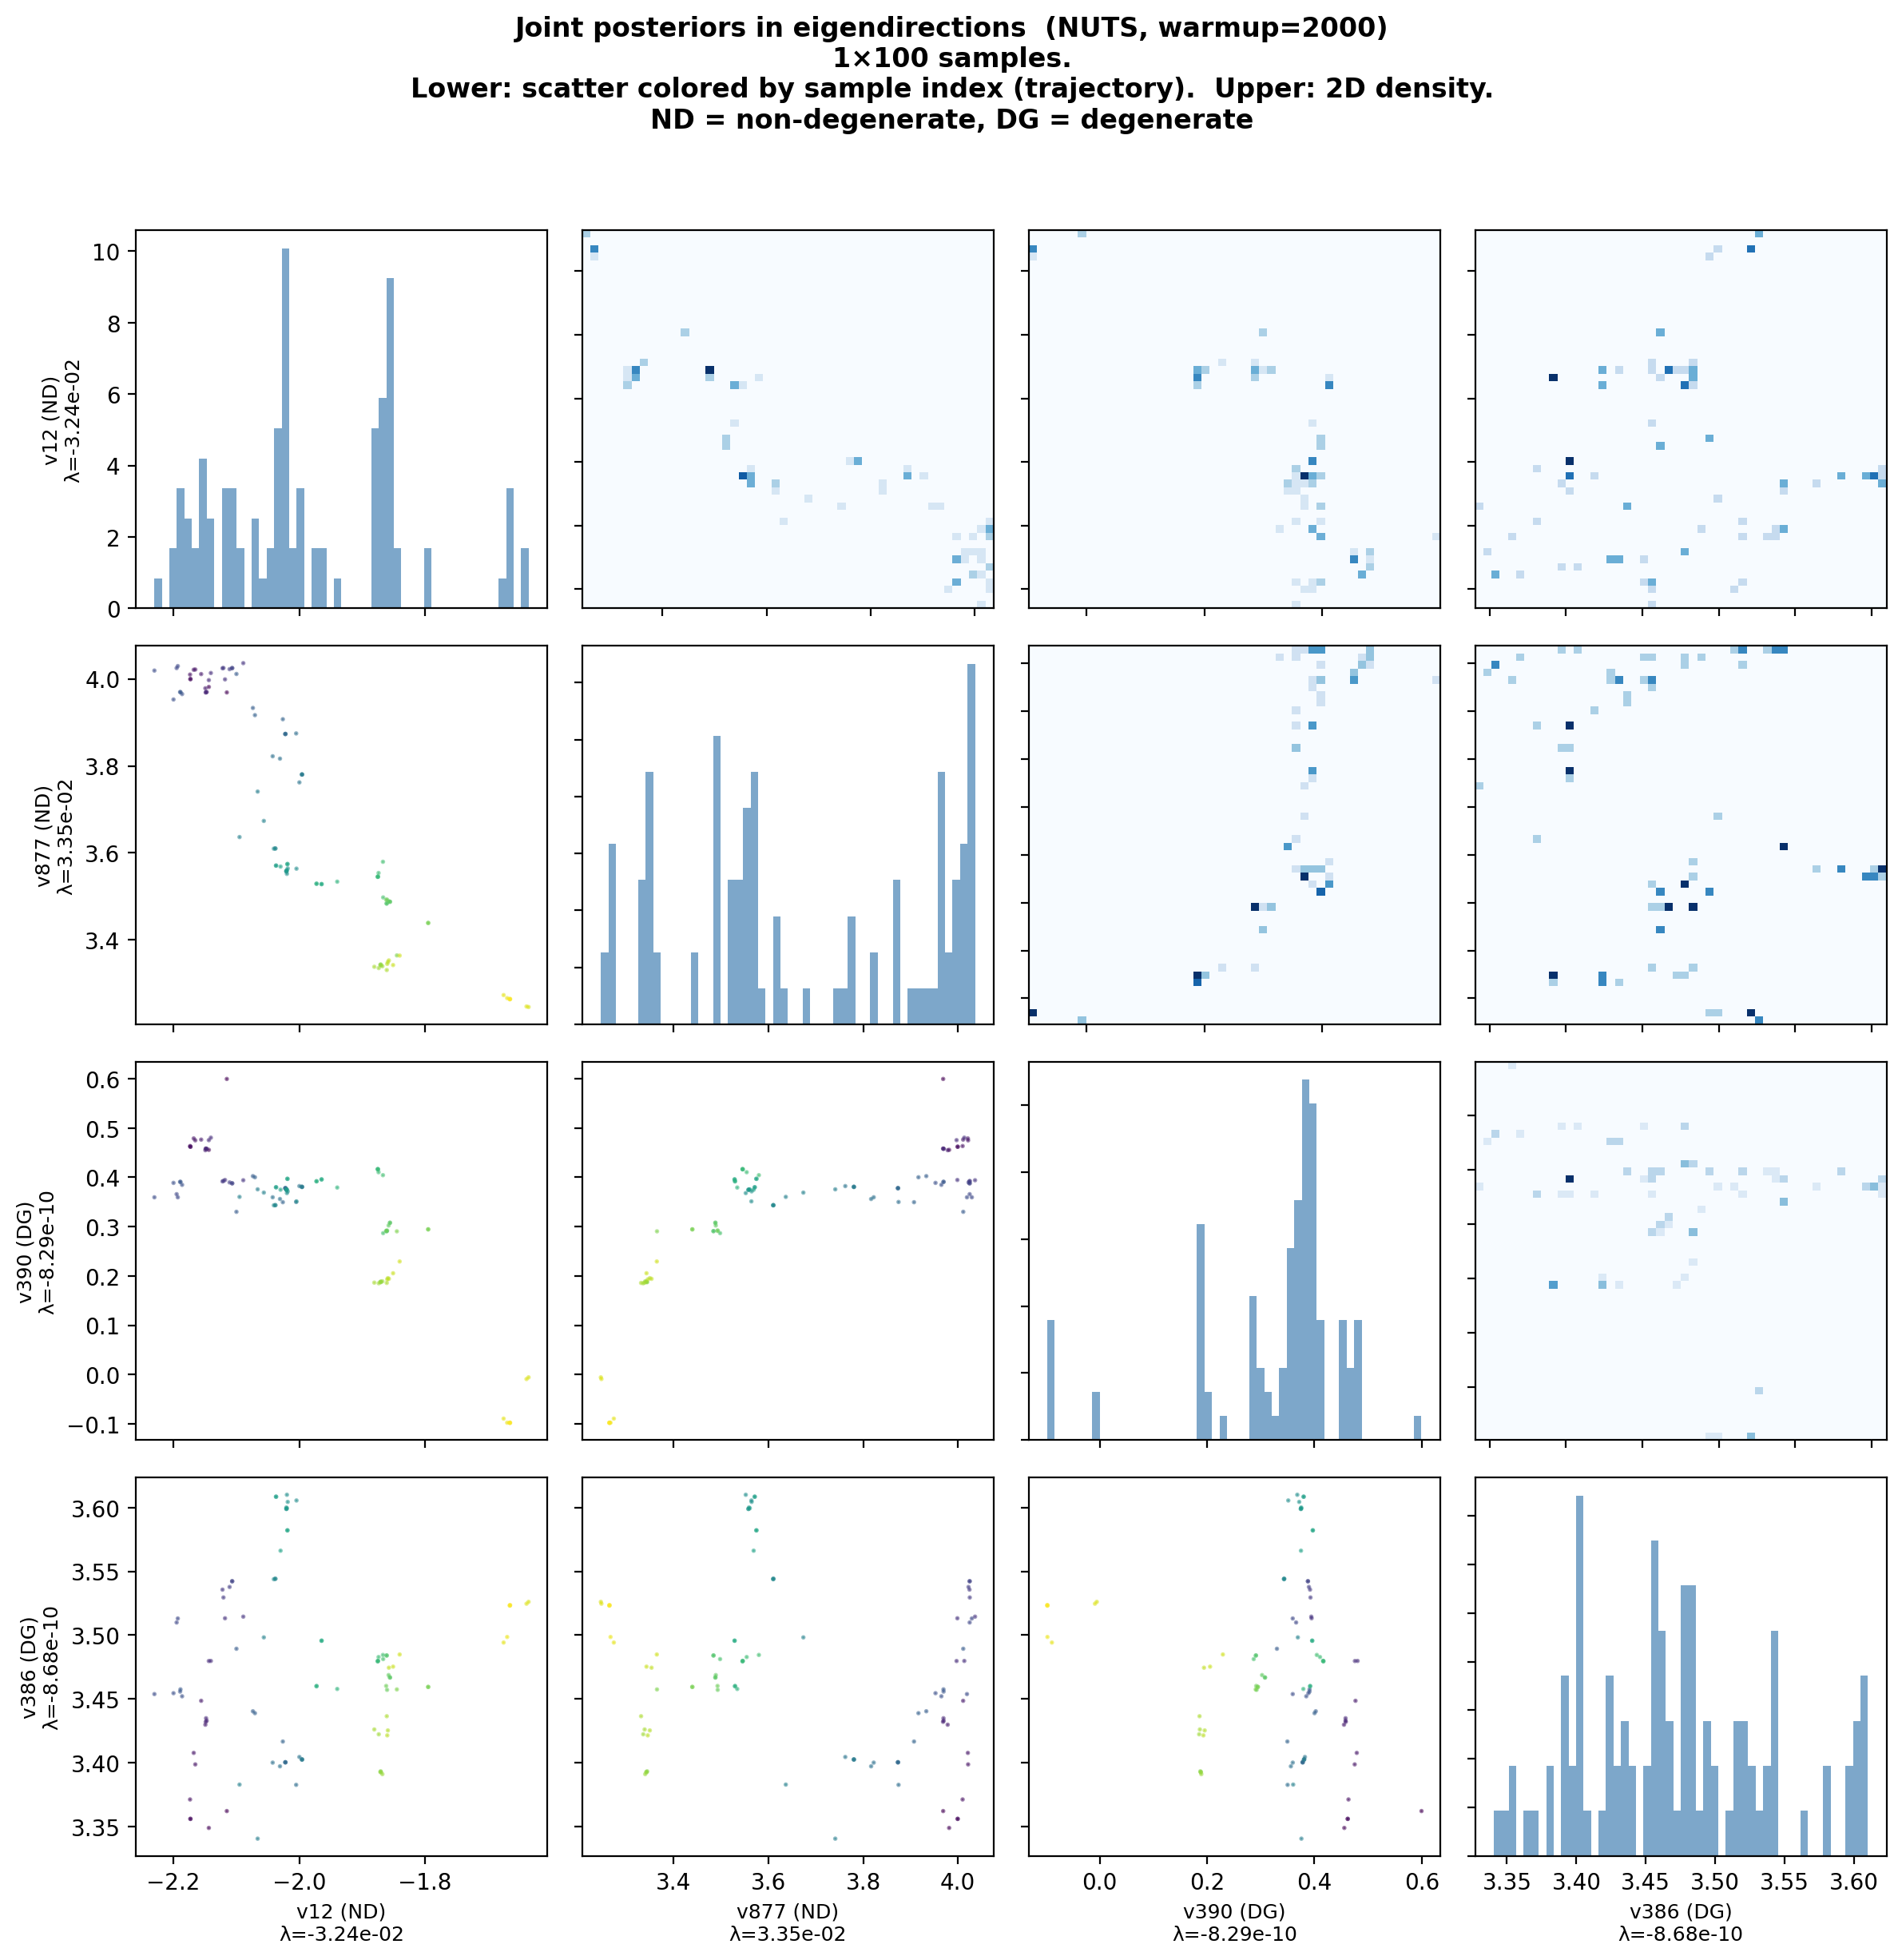

In [36]:
# === Corner plot: 2 non-degenerate + 2 degenerate eigendirections ===
import numpy as np

eigval_threshold = eigvals.max().item() * 1e-3
non_degen_idx = torch.where(eigvals.cpu().abs() > eigval_threshold)[0]
degen_idx = torch.where(eigvals.cpu().abs() <= eigval_threshold)[0]

# Pick 2 random from each group
rng = np.random.default_rng(42)
nd_pick = rng.choice(
    non_degen_idx.numpy(), size=min(2, len(non_degen_idx)), replace=False
)
dg_pick = rng.choice(degen_idx.numpy(), size=min(2, len(degen_idx)), replace=False)
selected = np.concatenate([nd_pick, dg_pick])

labels = []
for idx in selected:
    lam = eigvals[idx].item()
    kind = "ND" if idx in nd_pick else "DG"
    labels.append(f"v{idx} ({kind})\nλ={lam:.2e}")

# Project samples onto selected eigendirections
V_sel = eigvecs[:, selected].cpu().float()  # (d, 4)
z_sel = concat_samples @ V_sel  # (N_total, 4)
z_np = z_sel.numpy()

n_dirs = len(selected)
fig, axes = plt.subplots(n_dirs, n_dirs, figsize=(12, 12))

for i in range(n_dirs):
    for j in range(n_dirs):
        ax = axes[i, j]
        if i == j:
            # Diagonal: marginal histogram
            ax.hist(
                z_np[:, i],
                bins=50,
                density=True,
                color="steelblue",
                alpha=0.7,
                edgecolor="none",
            )
            ax.set_ylabel("density" if j == 0 else "")
        elif i > j:
            # Lower triangle: scatter with sample index as color (shows trajectory)
            colors = np.arange(len(z_np))
            ax.scatter(
                z_np[:, j],
                z_np[:, i],
                c=colors,
                cmap="viridis",
                s=1,
                alpha=0.5,
                rasterized=True,
            )
        else:
            # Upper triangle: 2D histogram / heatmap
            ax.hist2d(z_np[:, j], z_np[:, i], bins=50, cmap="Blues", density=True)

        if i == n_dirs - 1:
            ax.set_xlabel(labels[j], fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=9)
        else:
            ax.set_yticklabels([])

fig.suptitle(
    f"Joint posteriors in eigendirections  (NUTS, warmup={N_WARMUP})\n"
    f"{N_CHAINS_NUTS}×{N_SAMPLES_NUTS} samples.\n"
    "Lower: scatter colored by sample index (trajectory).  Upper: 2D density.\n"
    "ND = non-degenerate, DG = degenerate",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

## Parallel Tempering NUTS

Run NUTS with replica exchange (parallel tempering) to break autocorrelation
in degenerate directions.  The cold chain (β=1) targets the true posterior;
hot chains (β<1) explore a flattened landscape and feed configurations back
via DEO swap moves.

Temperature ladder: geometric spacing from β=1.0 down to β=0.1.
Swap criterion: log α = (β_j − β_k) · (ℓℓ_k − ℓℓ_j) where ℓℓ is untempered log-likelihood.

In [ ]:
# === Parallel Tempering configuration ===
import numpy as np
from torch_bdn.bn import BayesianNet
from torch_bdn.sampling import NUTS, Perturb, Sampler

# Temperature ladder — geometric spacing from β=1 to β=0.1
# 4 replicas: cold chain sees true posterior, hot chains explore freely.
# Geometric ratio ≈ 0.464 → should give ~20-40% swap acceptance for d_eff≈30.
N_REPLICAS = 4
BETA_MIN = 0.1
BETAS = list(np.geomspace(1.0, BETA_MIN, N_REPLICAS))
print(f"Temperature ladder ({N_REPLICAS} replicas):")
for i, b in enumerate(BETAS):
    print(f"  Chain {i}: β = {b:.4f}  (T = {1 / b:.2f})")

# Sampling configuration
N_WARMUP_PT = 5000  # Long warmup — need good mass matrix estimate
N_SAMPLES_PT = 5000  # Production samples per chain
MAX_TREE_DEPTH_PT = 6  # Optimal depth from previous experiments
TARGET_ACCEPT_PT = 0.65  # Slightly lower than default for singular geometry
SWAP_EVERY = 20  # Propose swaps every 20 samples

print("\nSampling config:")
print(f"  warmup = {N_WARMUP_PT}")
print(f"  samples = {N_SAMPLES_PT} per chain")
print(f"  max_tree_depth = {MAX_TREE_DEPTH_PT}")
print(f"  target_accept = {TARGET_ACCEPT_PT}")
print(f"  swap_every = {SWAP_EVERY}")
print(
    f"  Total gradient evals ≈ {N_REPLICAS} × {N_SAMPLES_PT} × 63 ≈ {N_REPLICAS * N_SAMPLES_PT * 63:,}"
)

In [ ]:
# === Run Parallel Tempering NUTS ===
bn = BayesianNet(
    model, loss_fn, make_prior_logp(mle_param, sigma=SIGMA_PRIOR), compile=True
)

result_pt = Sampler(bn, x_data, y_data).sample(
    config=NUTS(
        n_warmup=N_WARMUP_PT,
        step_size=0.01,
        max_tree_depth=MAX_TREE_DEPTH_PT,
        target_accept=TARGET_ACCEPT_PT,
        mass_matrix=M_posterior,
        adapt_mass_matrix=True,
    ),
    n_samples=N_SAMPLES_PT,
    n_chains=N_REPLICAS,
    init_strategy=Perturb(scale=0.1),
    swap_every=SWAP_EVERY,
    betas=BETAS,
)

# ── Summary ──
import collections

print(f"\n{'=' * 60}")
print("Parallel Tempering Results")
print(f"{'=' * 60}")
print(
    f"Swap rate: {result_pt.n_swaps_accepted}/{result_pt.n_swaps_proposed} "
    f"= {result_pt.swap_rate:.1%}"
)

for ci, ch in enumerate(result_pt.chains):
    diag = ch.diagnostics
    beta = diag.get("beta", BETAS[ci])
    tree_depths = diag.get("tree_depths", [])
    leapfrog_counts = diag.get("leapfrog_counts", [])
    n_hit_max = diag.get("n_hit_max_depth", 0)
    n_div = diag.get("n_divergences", 0)
    n = len(tree_depths) if tree_depths else N_SAMPLES_PT
    print(
        f"\nChain {ci} (β={beta:.4f}, T={1 / beta:.2f}): "
        f"accept={ch.acceptance_rate:.3f}  "
        f"ε={diag.get('adapted_step_size', diag.get('step_size', '?'))}"
    )
    print(
        f"  samples={len(ch.parameters)}  "
        f"max_depth_hits={n_hit_max}/{n}  divergences={n_div}/{n}"
    )
    if tree_depths:
        depth_counts = collections.Counter(tree_depths)
        print(f"  Tree depth distribution: {dict(sorted(depth_counts.items()))}")
    if leapfrog_counts:
        print(
            f"  Leapfrog: min={min(leapfrog_counts)} "
            f"median={sorted(leapfrog_counts)[len(leapfrog_counts) // 2]} "
            f"max={max(leapfrog_counts)}"
        )

In [ ]:
# ── Persist PT results ──
pt_path = DATA_DIR / "nuts_samples_pt.pt"

chains_payload_pt = []
for ci, ch in enumerate(result_pt.chains):
    chains_payload_pt.append(
        {
            "parameters": torch.stack(ch.parameters).cpu(),
            "acceptance_rate": ch.acceptance_rate,
            "diagnostics": ch.diagnostics,
            "beta": BETAS[ci],
        }
    )

torch.save(
    {
        "chains": chains_payload_pt,
        "config": {
            "n_replicas": N_REPLICAS,
            "betas": BETAS,
            "n_warmup": N_WARMUP_PT,
            "n_samples": N_SAMPLES_PT,
            "max_tree_depth": MAX_TREE_DEPTH_PT,
            "target_accept": TARGET_ACCEPT_PT,
            "swap_every": SWAP_EVERY,
            "sigma_prior": SIGMA_PRIOR,
            "dgp_regime": DGP_REGIME,
        },
        "swap_stats": {
            "n_proposed": result_pt.n_swaps_proposed,
            "n_accepted": result_pt.n_swaps_accepted,
            "swap_rate": result_pt.swap_rate,
            "history": result_pt.swap_history,
        },
        "mle_param": mle_param.cpu(),
        "eigvals": eigvals.cpu(),
        "eigvecs": eigvecs.cpu(),
        "M_posterior": M_posterior.cpu(),
    },
    pt_path,
)
print(f"✓ Saved PT samples to {pt_path}")
print(f"  Cold chain (β=1): {chains_payload_pt[0]['parameters'].shape}")
print(
    f"  Total samples across all replicas: "
    f"{sum(c['parameters'].shape[0] for c in chains_payload_pt)}"
)

In [ ]:
# === ACF comparison: Cold chain from PT vs plain NUTS ===
# Only use the cold chain (β=1) samples for inference.
cold_chain_samples = torch.stack(result_pt.chains[0].parameters).cpu().float()
V = eigvecs.cpu().float()
MAX_LAG_PT = min(200, cold_chain_samples.shape[0] // 4)

acf_cold = compute_acf_eigenbasis(cold_chain_samples, V, MAX_LAG_PT)
sort_idx = torch.argsort(eigvals.cpu(), descending=True)
acf_cold_sorted = acf_cold[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Left: PT cold chain
im = axes[0].imshow(
    acf_cold_sorted.numpy(),
    aspect="auto",
    cmap="RdBu_r",
    vmin=-0.3,
    vmax=1.0,
    interpolation="nearest",
    origin="upper",
)
axes[0].set_xlabel("Lag τ")
axes[0].set_ylabel("Eigendirection (sorted by λ)")
axes[0].set_title(f"PT Cold Chain (β=1)\n{cold_chain_samples.shape[0]} samples")

# Right: plain NUTS (from earlier result) for comparison
if "result" in dir() and hasattr(result, "chains"):
    plain_samples = torch.stack(result.chains[0].parameters).cpu().float()
    acf_plain = compute_acf_eigenbasis(plain_samples, V, MAX_LAG_PT)
    acf_plain_sorted = acf_plain[sort_idx]
    axes[1].imshow(
        acf_plain_sorted.numpy(),
        aspect="auto",
        cmap="RdBu_r",
        vmin=-0.3,
        vmax=1.0,
        interpolation="nearest",
        origin="upper",
    )
    axes[1].set_xlabel("Lag τ")
    axes[1].set_title(f"Plain NUTS (no PT)\n{plain_samples.shape[0]} samples")
else:
    axes[1].text(
        0.5,
        0.5,
        "No plain NUTS result\nfor comparison",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
    )
    axes[1].set_title("Plain NUTS (not available)")

# Mark degenerate boundary
eigvals_sorted = eigvals.cpu()[sort_idx]
eigval_threshold = eigvals.max().item() * 1e-3
n_nd = int((eigvals_sorted.abs() > eigval_threshold).sum())
for ax in axes:
    if 0 < n_nd < cold_chain_samples.shape[1]:
        ax.axhline(n_nd - 0.5, color="lime", lw=2, ls="--")

fig.suptitle(
    f"ACF comparison: Parallel Tempering vs Plain NUTS\n"
    f"swap_rate={result_pt.swap_rate:.1%}, {N_REPLICAS} replicas",
    fontsize=13,
    fontweight="bold",
)
plt.colorbar(im, ax=axes.tolist(), shrink=0.8, label="ACF")
plt.show()

# Summary statistics
acf10_pt = acf_cold_sorted[:, min(10, MAX_LAG_PT - 1)]
acf50_pt = acf_cold_sorted[:, min(50, MAX_LAG_PT - 1)]
print("\nPT Cold Chain ACF:")
print(f"  ACF@10: median={acf10_pt.median():.3f}  max={acf10_pt.max():.3f}")
print(f"  ACF@50: median={acf50_pt.median():.3f}  max={acf50_pt.max():.3f}")